In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import wandb
from tensorflow.keras.callbacks import ModelCheckpoint
from wandb.integration.keras import WandbCallback
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

I0000 00:00:1776683274.548242  988917 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
#Entrainer juste sur clean et mixed -> mixed est un melange de cross-out


In [3]:
# Binary classification

In [2]:
wandb.init(project="cross-out-detection")

callbacks = [
    WandbMetricsLogger(),  
    WandbModelCheckpoint(
        "best_model.keras",   
        monitor="val_loss",
        save_best_only=True,
        mode="min")]

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: linneahejsupergroup (linneahejsupergroup-lule-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING When using `save_best_only`, ensure that the `filepath` argument contains formatting placeholders like `{epoch:02d}` or `{batch:02d}`. This ensures correct interpretation of the logged artifacts.


In [3]:
checkpoint = ModelCheckpoint(
    "simple_CNN.h5",          # fichier de sauvegarde
    monitor="val_loss",       # métrique à surveiller
    save_best_only=True,      # 🔥 garde uniquement le meilleur
    mode="min",               # min pour loss, max pour accuracy
    verbose=1)


In [4]:
# Charge the dataset
# Parameters
img_size = (224, 224)
batch_size = 32

#load dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "Dataset/train/images",
    labels="inferred",
    label_mode="binary",
    class_names=["CLEAN", "MIXED"],  
    image_size=(224, 224),
    batch_size=32
)

# Load validation data
val_dataset = tf.keras.utils.image_dataset_from_directory(
    "Dataset/val/images",
    labels="inferred",
    label_mode="binary",
    class_names=["CLEAN", "MIXED"],  
    image_size=(224, 224),
    batch_size=32
)
#Load test data
test_dataset = tf.keras.utils.image_dataset_from_directory(
    "Dataset/train/images",
    labels="inferred",
    label_mode="binary",
    class_names=["CLEAN", "MIXED"],  
    image_size=(224, 224),
    batch_size=32
)
# Normalisation
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))

Found 95994 files belonging to 2 classes.


I0000 00:00:1776675363.590806  979838 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9154 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:21:00.0, compute capability: 7.5


Found 15118 files belonging to 2 classes.
Found 95994 files belonging to 2 classes.


In [5]:
#CNN

model = models.Sequential([
    
    # Small details captured
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    
    # Pooling 
    layers.MaxPooling2D((2,2)),
    
    # More complex details captured
    layers.Conv2D(64, (3,3), activation='relu'),
    
    # Pooling
    layers.MaxPooling2D((2,2)),
    
    # Flatten for dense layer
    layers.Flatten(),
    
    layers.Dense(64, activation='relu'),
    
    # Output (2 classes)
    layers.Dense(1, activation='sigmoid')])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# Compilation
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])

In [7]:
# Training

model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=[callbacks, checkpoint])

Epoch 1/10


I0000 00:00:1776675370.898113  980287 service.cc:153] XLA service 0x7f19380335d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776675370.898146  980287 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2080 Ti, Compute Capability 7.5 (Driver: 13.0.0; Runtime: 12.3.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1776675371.453496  980287 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776675372.366394  980287 cuda_dnn.cc:461] Loaded cuDNN version 91900
E0000 00:00:1776675373.150418  980287 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1776675373.776490  980287 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:

   7/3000 ━━━━━━━━━━━━━━━━━━━━ 1:05 22ms/step - accuracy: 0.4479 - loss: 4.1526

I0000 00:00:1776675377.589396  980287 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8767 - loss: 0.3846

...


Epoch 2: finished saving model to simple_CNN.h5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 70s 23ms/step - accuracy: 0.9310 - loss: 0.1431 - val_accuracy: 0.9202 - val_loss: 0.1574
Epoch 3/10
2998/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9395 - loss: 0.1141
Epoch 3: val_loss improved from 0.15745 to 0.15179, saving model to simple_CNN.h5



Epoch 3: finished saving model to simple_CNN.h5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 68s 23ms/step - accuracy: 0.9390 - loss: 0.1152 - val_accuracy: 0.9223 - val_loss: 0.1518
Epoch 4/10
2998/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9421 - loss: 0.1029
Epoch 4: val_loss improved from 0.15179 to 0.14895, saving model to simple_CNN.h5



Epoch 4: finished saving model to simple_CNN.h5
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 69s 23ms/step - accuracy: 0.9428 - loss: 0.1022 - val_accuracy: 0.9236 - val_loss: 0.1490
Epoch 5/10
2998/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9460 - loss: 0.0927
Epoch 5: val_loss did not improve from 0.14895
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 64s 21ms/step - accuracy: 0.9460 - loss: 0.0923 - val_accuracy: 0.9212 - val_loss: 0.1598
Epoch 6/10
 145/3000 ━━━━━━━━━━━━━━━━━━━━ 57s 20ms/step - accuracy: 0.9426 - loss: 0.0929

wandb: WARNING Artifact "run_1hhfng57_model" already exists with the same content. No new version will be created.


2998/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9466 - loss: 0.0890
Epoch 6: val_loss did not improve from 0.14895
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 64s 21ms/step - accuracy: 0.9471 - loss: 0.0876 - val_accuracy: 0.9223 - val_loss: 0.1573
Epoch 7/10
2998/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9485 - loss: 0.0867
Epoch 7: val_loss did not improve from 0.14895
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 64s 21ms/step - accuracy: 0.9482 - loss: 0.0867 - val_accuracy: 0.9085 - val_loss: 0.2012
Epoch 8/10
2998/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9492 - loss: 0.0831
Epoch 8: val_loss did not improve from 0.14895
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 64s 21ms/step - accuracy: 0.9489 - loss: 0.0828 - val_accuracy: 0.9170 - val_loss: 0.1843
Epoch 9/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9499 - loss: 0.0959
Epoch 9: val_loss did not improve from 0.14895
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 64s 21ms/step - accuracy: 0.9495 - loss: 0.0885 - val_accuracy: 0.9206 - 

In [8]:
model = load_model("simple_CNN.h5")

In [9]:
# Evaluation
test_loss, test_acc = model.evaluate(test_dataset)
print("Accuracy :", test_acc)

2997/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9467 - loss: 0.0884

E0000 00:00:1776676279.749430  980285 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1776676280.124139  980285 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


3000/3000 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - accuracy: 0.9472 - loss: 0.0890
Accuracy : 0.9471946358680725


In [10]:
y_pred_probs = model.predict(test_dataset)
y_pred = (y_pred_probs > 0.5).astype(int).reshape(-1)

y_true = np.concatenate([y for x, y in test_dataset], axis=0).astype(int)

cm = confusion_matrix(y_true, y_pred)
print(cm)

3000/3000 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step
[[25533 22464]
 [25513 22484]]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


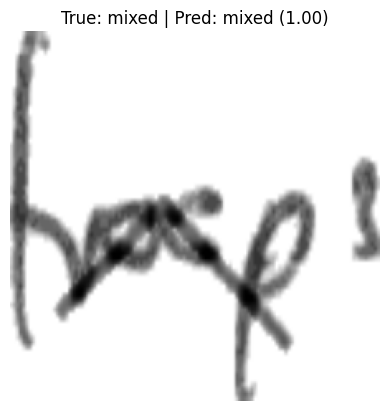

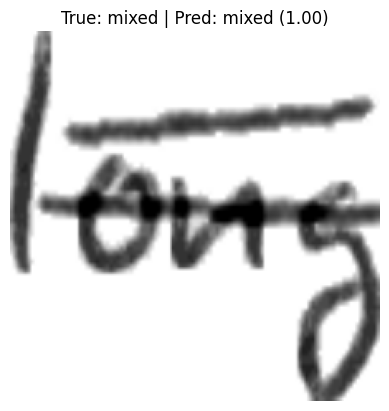

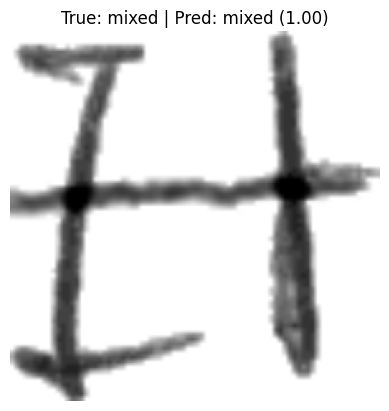

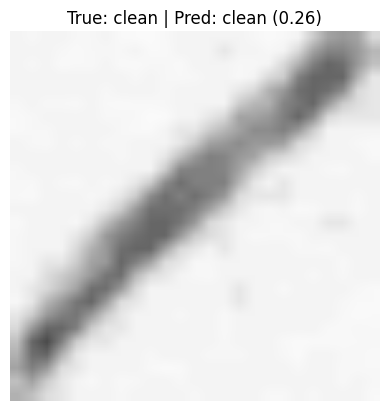

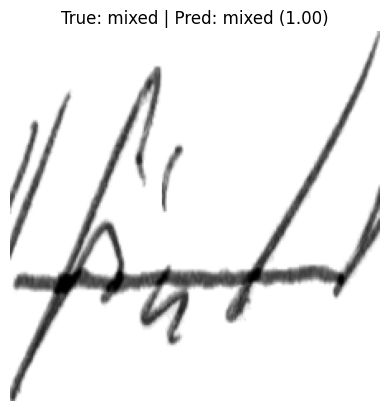

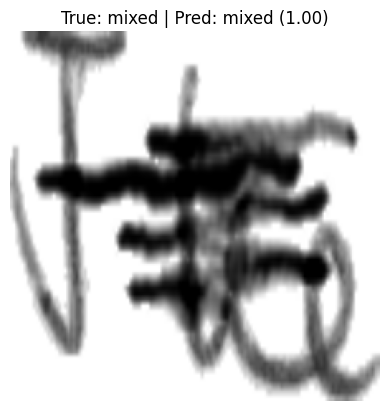

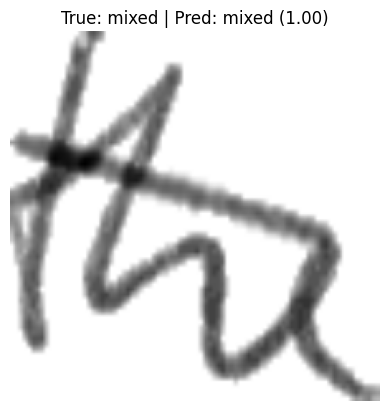

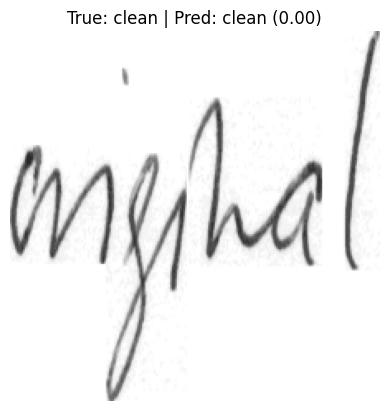

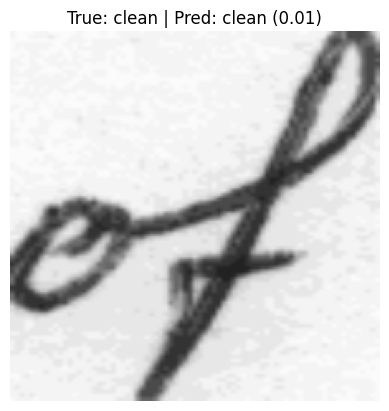

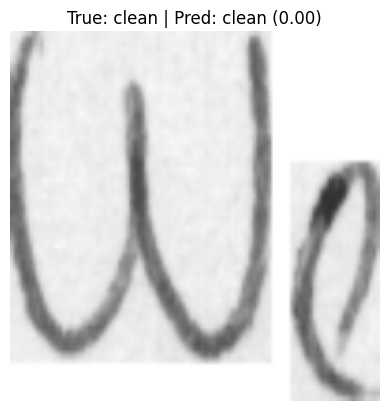

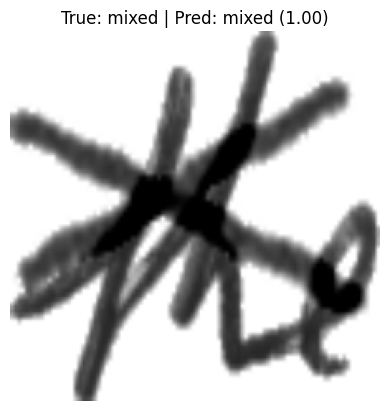

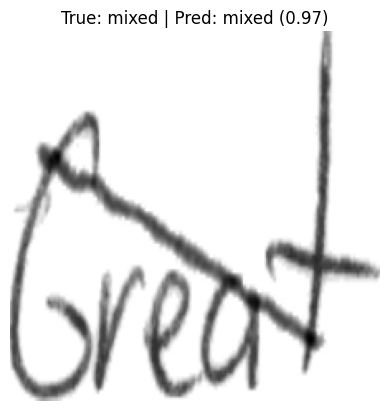

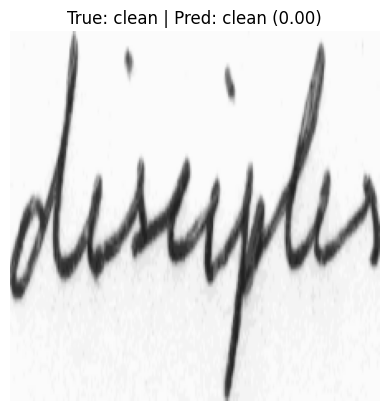

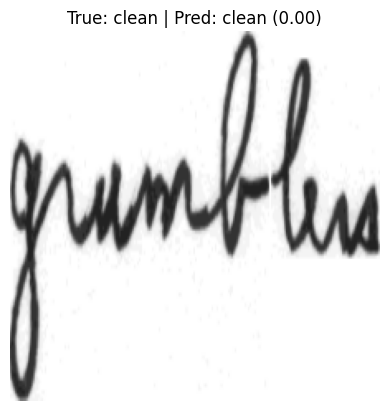

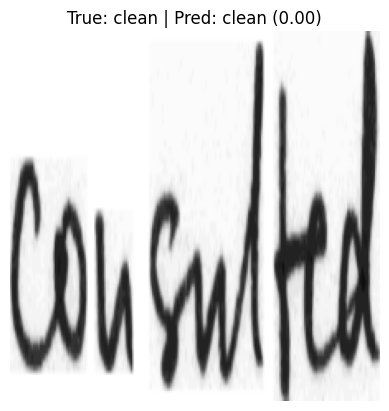

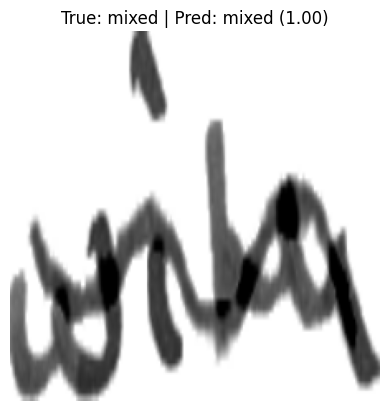

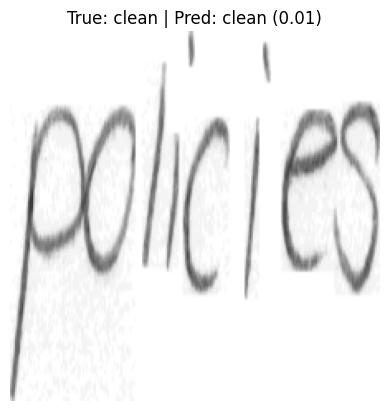

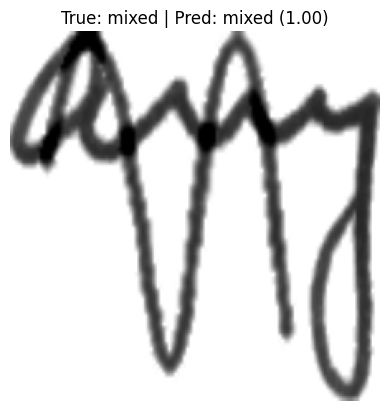

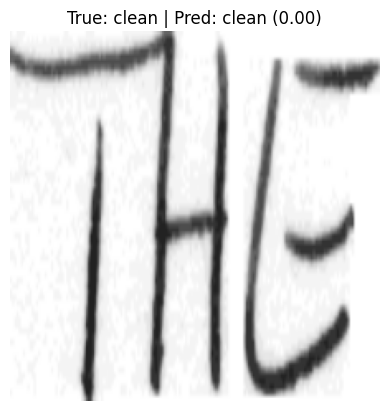

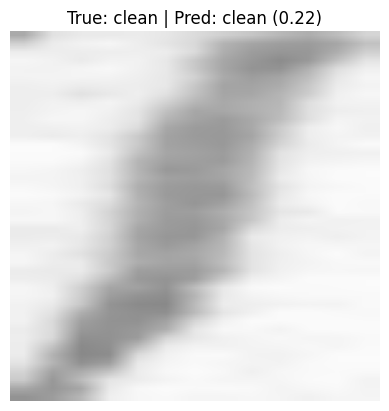

In [15]:
class_names = ["clean", "mixed"]  # adapte si besoin

for images, labels in test_dataset.take(1):
    preds = model.predict(images)

    for i in range(20):
        plt.imshow(images[i].numpy())
        
        true_label = int(labels[i].numpy()[0])
        pred_label = int(preds[i][0] > 0.5)

        plt.title(f"True: {class_names[true_label]} | Pred: {class_names[pred_label]} ({preds[i][0]:.2f})")
        plt.axis("off")
        plt.show()

In [16]:
y_true = np.concatenate([y for x, y in test_dataset], axis=0)
print(np.unique(y_true, return_counts=True))

(array([0., 1.], dtype=float32), array([47997, 47997]))


In [15]:
print("y_pred:", np.unique(y_pred, return_counts=True))

y_pred: (array([0]), array([95994]))


In [12]:
wandb.finish()

epoch/accuracy,▁▅▆▇█
epoch/epoch,▁▃▅▆█
epoch/learning_rate,▁▁▁▁▁
epoch/loss,█▄▂▂▁
epoch/val_accuracy,▁▅▇██
epoch/val_loss,█▄▃▁▂
epoch/accuracy,0.9446
epoch/epoch,4
epoch/learning_rate,0.001
epoch/loss,0.09453
epoch/val_accuracy,0.92234


In [ ]:
# Multi-class classification

In [3]:
wandb.init(project="cross-out-detection")

callbacks = [
    WandbMetricsLogger(),  
    WandbModelCheckpoint(
        "best_model.keras",   
        monitor="val_loss",
        save_best_only=True,
        mode="min")]

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: linneahejsupergroup (linneahejsupergroup-lule-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING When using `save_best_only`, ensure that the `filepath` argument contains formatting placeholders like `{epoch:02d}` or `{batch:02d}`. This ensures correct interpretation of the logged artifacts.


In [4]:
checkpoint = ModelCheckpoint(
    "multiclass_CNN.h5",          # fichier de sauvegarde
    monitor="val_loss",       # métrique à surveiller
    save_best_only=True,      # 🔥 garde uniquement le meilleur
    mode="min",               # min pour loss, max pour accuracy
    verbose=1)


In [5]:
# Charge the dataset
# Parameters
img_size = (224, 224)
batch_size = 32

#load dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "Dataset/train/images",
    labels="inferred",
    label_mode="int",
    class_names=["CROSS", "DIAGONAL", "DOUBLE_LINE","SCRATCH", "SINGLE_LINE", "WAVE", "ZIG_ZAG", "CLEAN"],  
    image_size=(224, 224),
    batch_size=32
)

# Load validation data
val_dataset = tf.keras.utils.image_dataset_from_directory(
    "Dataset/val/images",
    labels="inferred",
    label_mode="int",
    class_names=["CROSS", "DIAGONAL", "DOUBLE_LINE","SCRATCH", "SINGLE_LINE", "WAVE", "ZIG_ZAG", "CLEAN"],  
    image_size=(224, 224),
    batch_size=32
)
#Load test data
test_dataset = tf.keras.utils.image_dataset_from_directory(
    "Dataset/train/images",
    labels="inferred",
    label_mode="int",
    class_names=["CROSS", "DIAGONAL", "DOUBLE_LINE","SCRATCH", "SINGLE_LINE", "WAVE", "ZIG_ZAG", "CLEAN"],  
    image_size=(224, 224),
    batch_size=32
)
# Normalisation
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))

Found 383976 files belonging to 8 classes.


I0000 00:00:1776683308.706276  988917 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9154 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:21:00.0, compute capability: 7.5


Found 60472 files belonging to 8 classes.
Found 383976 files belonging to 8 classes.


In [6]:
#CNN

model = models.Sequential([
    
    # Small details captured
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    
    # Pooling 
    layers.MaxPooling2D((2,2)),
    
    # More complex details captured
    layers.Conv2D(64, (3,3), activation='relu'),
    
    # Pooling
    layers.MaxPooling2D((2,2)),
    
    # More complex details captured
    layers.Conv2D(128, (3,3), activation='relu'),
    
    # Pooling
    layers.MaxPooling2D((2,2)),
    
    # Flatten for dense layer
    layers.Flatten(),
    
    layers.Dense(64, activation='relu'),
    
    # Output (8 classes)
    layers.Dense(8, activation='softmax')])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# Compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [ ]:
# Training
model.fit(train_dataset, epochs=10, validation_data=val_dataset, callbacks = [callbacks, checkpoint])

Epoch 1/10


I0000 00:00:1776683335.204910  989361 service.cc:153] XLA service 0x7fa39c008970 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776683335.204961  989361 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2080 Ti, Compute Capability 7.5 (Driver: 13.0.0; Runtime: 12.3.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1776683335.743304  989361 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776683336.731542  989361 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1776683336.757537  989361 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1994__.39
E0000 00:00:1776683337.833648  989361 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1776683338.451095  989361 cuda_timer.cc:87] Delay kernel timed out: mea

    7/12000 ━━━━━━━━━━━━━━━━━━━━ 5:11 26ms/step - accuracy: 0.1564 - loss: 4.0623

I0000 00:00:1776683343.720403  989361 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


11997/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7228 - loss: 0.7095

...


Epoch 1: val_loss improved from None to 0.41657, saving model to multiclass_CNN.h5



Epoch 1: finished saving model to multiclass_CNN.h5
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 314s 25ms/step - accuracy: 0.7962 - loss: 0.5048 - val_accuracy: 0.8274 - val_loss: 0.4166
Epoch 2/10
11999/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8532 - loss: 0.3583
Epoch 2: val_loss improved from 0.41657 to 0.39883, saving model to multiclass_CNN.h5



Epoch 2: finished saving model to multiclass_CNN.h5
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 295s 25ms/step - accuracy: 0.8596 - loss: 0.3425 - val_accuracy: 0.8448 - val_loss: 0.3988
Epoch 3/10
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8744 - loss: 0.3075
Epoch 3: val_loss did not improve from 0.39883
12000/12000 ━━━━━━━━━━━━━━━━━━━━ 293s 24ms/step - accuracy: 0.8769 - loss: 0.3015 - val_accuracy: 0.8317 - val_loss: 0.4607
Epoch 4/10
  437/12000 ━━━━━━━━━━━━━━━━━━━━ 4:31 24ms/step - accuracy: 0.8832 - loss: 0.2936

wandb: WARNING Artifact "run_jdkjdt8a_model" already exists with the same content. No new version will be created.


 3271/12000 ━━━━━━━━━━━━━━━━━━━━ 3:22 23ms/step - accuracy: 0.8847 - loss: 0.2843

In [ ]:
# Evaluation
test_loss, test_acc = model.evaluate(test_dataset)
print("Accuracy :", test_acc)

In [ ]:
# récupère automatiquement les noms des classes
class_names = test_dataset.class_names  

for images, labels in test_dataset.take(1):
    preds = model.predict(images)

    for i in range(6):
        plt.imshow(images[i].numpy())  # ⚠️ pas de astype si normalisé

        # labels vrais
        true_label = int(labels[i].numpy())

        # prédiction
        pred_label = np.argmax(preds[i])

        plt.title(
            f"True: {class_names[true_label]} | "
            f"Pred: {class_names[pred_label]} ({np.max(preds[i]):.2f})"
        )
        plt.axis("off")
        plt.show()